In [40]:
import numpy as np
import MDAnalysis as mda
import sys
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from utility import Ticker

sys.path.append("../Scripts/")
from icecoder import IceCoder

## OpenMM Simulation of mW Ice crystallization

We have run a molecular dynamics simulation in `OpenMM` using custom 2-body and 3-body Stillinger-Weber potentials to represent the monatomic water (mW) model. We started from a supercooled configuration at 250 K with a crystalline Ice-Ih slab in the center acting as a seed, while the remaining atoms were disordered.

Let's load the projection analysis of the crystallization trajectory.

In [41]:
traj = mda.Universe("../data/seeded_mW_scaled.gro", "../data/simulation_mW_long_scaled.dcd", refresh_offsets = True)

/home/dm/Soft/miniconda3/envs/pathgennie/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [34]:
ic = IceCoder(
    scaler="../NoteBooks/Saved/scaler.save",
    model="../NoteBooks/Saved/pyvenc.pt",
    clf="../NoteBooks/Saved/svm.save"
)
ic.featurizer(mda_universe=traj, start=0, stop=250)
ic.project()

/home/dm/Soft/miniconda3/envs/pathgennie/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dm/Soft/miniconda3/envs/pathgennie/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.3.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
100%|██████████| 250/250 [00:06<00:00, 37.35it/s]


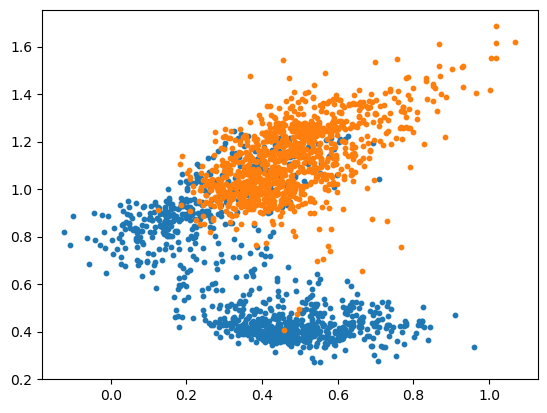

In [38]:
plt.scatter(ic.projected[:,0][:1024], ic.projected[:,1][:1024], s = 10)
plt.scatter(ic.projected[:,0][-1024:], ic.projected[:,1][-1024:], s = 10)